# DigitAI

## Transformando dígitos em inteligência

### Mini-Projeto Avaliativo — Módulo 2

Neste projeto, vamos construir uma solução capaz de reconhecer dígitos manuscritos. A ideia é entender como uma imagem pode ser transformada em dados e como modelos de Machine Learning usam essas informações para classificar números de 0 a 9.

---

## Objetivo do projeto

O DigitAI tem como objetivo construir um pipeline preditivo multiclasse para identificar dígitos manuscritos de 0 a 9 a partir do dataset MNIST (`mnist_784`).

Ao longo do projeto, vamos conhecer a estrutura dos dados, preparar as imagens para o treinamento, comparar três modelos preditivos e avaliar como cada um deles se comporta. Também serão realizados testes de robustez e uma etapa de predição com imagens manuscritas próprias.

# Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

Antes de treinar qualquer modelo, precisamos entender a base de dados que será utilizada. Nesta primeira etapa, vamos carregar o dataset MNIST e observar como as imagens e seus rótulos estão organizados.

Também vamos verificar o tamanho das matrizes de dados, conferir se os dígitos de 0 a 9 estão bem distribuídos e visualizar alguns exemplos. Por fim, vamos explicar como uma imagem de 28 × 28 pixels é convertida em um vetor de 784 características para que os modelos consigam interpretar essas informações.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

In [22]:
print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto"
)

print("Download finalizado.")

Baixando o dataset MNIST...
Download finalizado.


In [23]:
X = mnist.data
y = mnist.target

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (70000, 784)
y.shape: (70000,)


### Distribuição dos rótulos (0–9)

A tabela abaixo mostra quantas imagens existem para cada dígito no MNIST.

In [24]:
# Contar a quantidade de cada dígito
label_counts = pd.Series(y).value_counts().sort_index()

# Criar DataFrame
df_labels = pd.DataFrame({
    "label": label_counts.index.astype(int),
    "count": label_counts.values
})

print(df_labels)

   label  count
0      0   6903
1      1   7877
2      2   6990
3      3   7141
4      4   6824
5      5   6313
6      6   6876
7      7   7293
8      8   6825
9      9   6958


### Gráfico de distribuição dos rótulos

O gráfico abaixo mostra a quantidade de imagens para cada dígito (0 a 9).

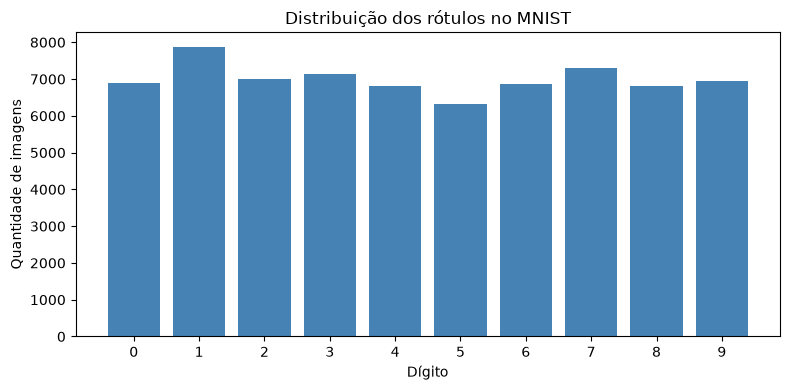

In [25]:
plt.figure(figsize=(8, 4))
plt.bar(df_labels["label"], df_labels["count"], color="steelblue")
plt.xticks(range(10))
plt.xlabel("Dígito")
plt.ylabel("Quantidade de imagens")
plt.title("Distribuição dos rótulos no MNIST")
plt.tight_layout()
plt.show()

### Visualização de exemplos das imagens

As imagens do MNIST são armazenadas inicialmente como vetores com 784 pixels.
Cada vetor será reorganizado em uma matriz de 28 × 28 pixels para visualização.

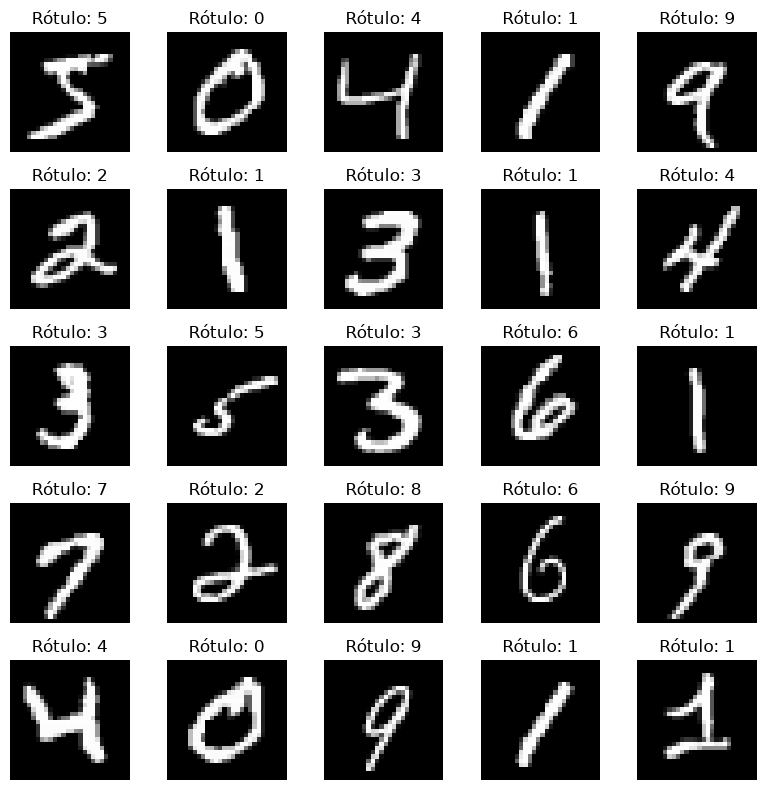

In [26]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Rótulo: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observações sobre as imagens

A visualização mostra exemplos de números escritos à mão presentes no dataset MNIST. Mesmo representando os mesmos dígitos, as imagens variam bastante porque cada pessoa escreve de um jeito diferente: alguns traços são mais grossos, outros mais finos, alguns números ficam inclinados e outros ocupam mais espaço na imagem.

Também é possível perceber que alguns dígitos podem se parecer entre si dependendo da forma como foram escritos, como o 1 e o 7, ou o 3 e o 5. Essas diferenças tornam a tarefa de classificação mais interessante, pois o modelo precisará aprender a reconhecer padrões mesmo quando os números não são idênticos.

Os rótulos exibidos acima de cada imagem representam o dígito correto informado pelo dataset. Nesta etapa, eles servem como referência para entender os dados antes de treinar os modelos de classificação.

### Como as imagens são representadas

Cada imagem do MNIST possui 28 pixels de altura e 28 pixels de largura. Por isso, quando observamos a imagem como uma matriz, ela tem o formato 28 × 28.

Cada pixel possui um valor de intensidade entre 0 e 255. O valor 0 representa o preto, enquanto o valor 255 representa o branco. Os valores intermediários representam tons de cinza. Nas imagens exibidas, os números aparecem em tons claros e o fundo é escuro porque usamos o mapa de cores `gray` na visualização.

Para que algoritmos de Machine Learning possam trabalhar com essas imagens, a matriz 28 × 28 é transformada em um único vetor com 784 posições, pois 28 × 28 = 784. Cada posição desse vetor representa a intensidade de um pixel da imagem.

Assim, a matriz `X` possui 70.000 linhas, uma para cada imagem, e 784 colunas, uma para cada pixel. Já o vetor `y` guarda o rótulo correto de cada imagem, ou seja, o dígito que ela representa.

## Fase 2 — Pré-processamento e divisão dos dados

Nesta etapa, os dados serão divididos em conjuntos de treino, validação e teste. Também será feita a normalização dos pixels para que seus valores passem da escala original de 0 a 255 para o intervalo de 0 a 1.

A divisão será estratificada, ou seja, cada conjunto manterá aproximadamente a mesma proporção de dígitos de 0 a 9 presente no dataset original.

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# Primeiro: separar 80% para treino + validação e 20% para teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Segundo: dividir os 80% restantes em 70% treino e 10% validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

### Conferindo a divisão dos dados

Depois de separar as imagens, é importante conferir se cada grupo ficou com a quantidade esperada de exemplos.

O conjunto de treino será usado para ensinar os modelos a reconhecer os dígitos. A validação ajudará a comparar configurações e evitar decisões baseadas apenas no treino. Já o conjunto de teste ficará reservado para verificar, no final, como o modelo se comporta com imagens que não foram usadas durante o desenvolvimento.

In [29]:
print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (49000, 784) (49000,)
Validação: (7000, 784) (7000,)
Teste: (14000, 784) (14000,)


### Normalizando os pixels

Até aqui, cada pixel das imagens possui um valor entre 0 e 255. Para facilitar o trabalho dos modelos, vamos colocar esses valores em uma escala menor, entre 0 e 1.

Essa mudança não altera o desenho do número. Ela apenas transforma a intensidade de cada pixel em uma escala mais adequada para os cálculos. Isso é importante principalmente para modelos que calculam distâncias entre imagens ou ajustam pesos durante o treinamento, pois valores em escalas muito altas podem dificultar esse processo.

In [30]:
X_train_norm = X_train.astype("float32") / 255.0
X_val_norm = X_val.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print("Treino - mínimo:", X_train_norm.min())
print("Treino - máximo:", X_train_norm.max())

print("Validação - mínimo:", X_val_norm.min())
print("Validação - máximo:", X_val_norm.max())

print("Teste - mínimo:", X_test_norm.min())
print("Teste - máximo:", X_test_norm.max())

Treino - mínimo: 0.0
Treino - máximo: 1.0
Validação - mínimo: 0.0
Validação - máximo: 1.0
Teste - mínimo: 0.0
Teste - máximo: 1.0


### Conferindo a proporção dos dígitos

Como a divisão foi feita de forma estratificada, esperamos encontrar proporções parecidas dos dígitos de 0 a 9 nos conjuntos de treino, validação e teste.

Essa conferência ajuda a garantir que nenhum conjunto ficou com uma quantidade muito diferente de algum dígito, o que poderia prejudicar o treinamento ou tornar a avaliação injusta.

In [31]:
distribuicao_divisao = pd.DataFrame({
    "Treino (%)": pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    "Validação (%)": pd.Series(y_val).value_counts(normalize=True).sort_index() * 100,
    "Teste (%)": pd.Series(y_test).value_counts(normalize=True).sort_index() * 100
})

distribuicao_divisao.round(2)

,Treino (%),Validação (%),Teste (%)
0,9.86,9.86,9.86
1,11.25,11.26,11.25
2,9.99,9.99,9.99
3,10.20,10.20,10.20
4,9.75,9.74,9.75
5,9.02,9.01,9.02
6,9.82,9.83,9.82
7,10.42,10.41,10.42
8,9.75,9.76,9.75
9,9.94,9.94,9.94


### Conclusão da etapa de pré-processamento

A divisão dos dados foi realizada de forma estratificada e manteve uma proporção muito parecida dos dígitos em todos os conjuntos. Dessa forma, o treino, a validação e o teste representam bem a variedade presente no dataset original.

Além disso, os pixels foram normalizados para a escala de 0 a 1. Essa preparação deixa os dados prontos para os próximos passos, principalmente para modelos que utilizam distância entre imagens ou ajustam pesos durante o treinamento.

## Fase 3 — Treinamento dos modelos

Nesta etapa, três modelos serão treinados para classificar os dígitos manuscritos: KNN, Random Forest e MLP. Os três recebem as mesmas imagens normalizadas, mas usam estratégias diferentes para encontrar padrões.

A comparação entre eles ajudará a identificar qual modelo apresenta melhor equilíbrio entre desempenho e tempo de treinamento.

In [32]:
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

### Modelo 1 — KNN

O KNN classifica uma imagem procurando exemplos parecidos entre as imagens usadas no treino. Em vez de criar uma regra fixa, ele compara a imagem nova com os exemplos mais próximos e escolhe o dígito que aparece com mais força nessa comparação.

Neste modelo, foram usados 3 vizinhos (`n_neighbors=3`). Essa quantidade permite que a classificação não dependa de uma única imagem, mas ainda permaneça sensível a exemplos muito semelhantes.

Também foi utilizado `weights="distance"`. Assim, os vizinhos que estão mais próximos da imagem analisada têm mais influência no resultado do que os vizinhos mais distantes. O parâmetro `n_jobs=-1` permite aproveitar os núcleos disponíveis do processador durante os cálculos.

In [33]:
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

start_time = time.time()
knn_model.fit(X_train_norm, y_train)
knn_training_time = time.time() - start_time

print(f"Tempo de treinamento do KNN: {knn_training_time:.2f} segundos")

Tempo de treinamento do KNN: 0.10 segundos


### Modelo 2 — Random Forest

A Random Forest toma decisões combinando várias árvores de decisão. Cada árvore observa padrões diferentes nos pixels das imagens e, ao final, todas as árvores votam no dígito mais provável.

Foram usadas 100 árvores para tornar a decisão mais estável e uma profundidade máxima de 20 níveis. Esse limite ajuda a evitar que as árvores se ajustem demais aos exemplos de treino.

In [34]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

start_time = time.time()
random_forest_model.fit(X_train_norm, y_train)
random_forest_training_time = time.time() - start_time

print(f"Tempo de treinamento da Random Forest: {random_forest_training_time:.2f} segundos")

Tempo de treinamento da Random Forest: 42.86 segundos


### Modelo 3 — MLP

A MLP é uma rede neural simples formada por neurônios que aprendem relações entre os pixels das imagens. Diferente do KNN e da Random Forest, ela ajusta pesos internos para reconhecer padrões associados a cada dígito.

Foi utilizada uma camada escondida com 128 neurônios (`hidden_layer_sizes=(128,)`). Essa camada permite que a rede encontre combinações mais complexas entre os pixels. O limite de 30 iterações (`max_iter=30`) foi escolhido para manter um tempo de treinamento adequado ao projeto.

Durante o treinamento, a MLP atingiu o limite de iterações antes de concluir totalmente a convergência. Mesmo assim, o modelo foi treinado e será avaliado normalmente. Essa escolha representa um equilíbrio entre tempo de execução e desempenho.

In [35]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    max_iter=30,
    random_state=42
)

start_time = time.time()
mlp_model.fit(X_train_norm, y_train)
mlp_training_time = time.time() - start_time

print(f"Tempo de treinamento do MLP: {mlp_training_time:.2f} segundos")

Tempo de treinamento do MLP: 38.70 segundos


d:\meusdocumentosoficial\SCTec\IA\aulas\modulo2\mini_projeto\digit-ai\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


A MLP atingiu o limite de 30 iterações antes de completar totalmente a convergência. Esse limite foi mantido para equilibrar o tempo disponível e o custo computacional do experimento. Mesmo com o aviso, o modelo foi treinado e será avaliado no conjunto de teste.

## Fase 4 — Avaliação dos Modelos

Nesta fase, os três modelos treinados (KNN, Random Forest e MLP) são usados para prever os dígitos nas imagens do conjunto de teste. O objetivo é comparar o desempenho de cada modelo em termos de acurácia, F1-score (macro) e tempo de predição.

Para cada modelo, são geradas:
- as previsões para as imagens de teste;
- a acurácia, que mede a proporção de previsões corretas;
- o F1-score (macro), que considera equilíbrio entre precisão e revocação para todas as classes;
- a matriz de confusão, que mostra quantas vezes cada dígito foi confundido com outros;
- o tempo gasto para realizar as previsões.

Essas métricas permitem identificar qual modelo apresenta melhor equilíbrio entre desempenho e custo computacional.

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Previsões no conjunto de teste normalizado
y_pred_knn = knn_model.predict(X_test_norm)
y_pred_random_forest = random_forest_model.predict(X_test_norm)
y_pred_mlp = mlp_model.predict(X_test_norm)

# Organização das previsões
previsoes = {
    "KNN": y_pred_knn,
    "Random Forest": y_pred_random_forest,
    "MLP": y_pred_mlp
}

# Cálculo das métricas exigidas
resultados = []

for nome, y_pred in previsoes.items():
    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision ponderada": precision_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "Recall ponderado": recall_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "F1-Score ponderado": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    })

resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,Accuracy,Precision ponderada,Recall ponderado,F1-Score ponderado
0,KNN,0.972143,0.972371,0.972143,0.972110
1,Random Forest,0.964786,0.964787,0.964786,0.964760
2,MLP,0.979929,0.979962,0.979929,0.979927


### Matrizes de Confusão

As matrizes de confusão mostram, para cada modelo, quantas vezes cada dígito foi classificado corretamente e quantas vezes foi confundido com outros dígitos.

Cada linha representa os valores reais e cada coluna representa os valores previstos. Os valores na diagonal principal indicam as previsões corretas.

Abaixo são apresentadas as matrizes para os três modelos: KNN, Random Forest e MLP.

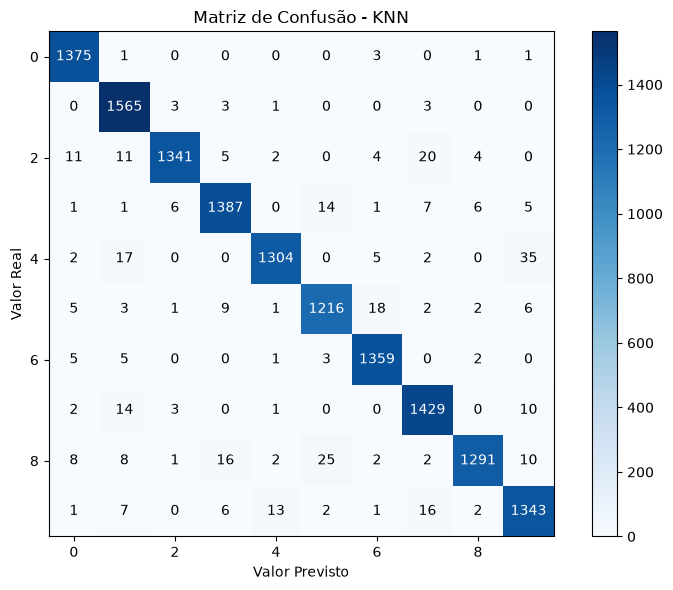

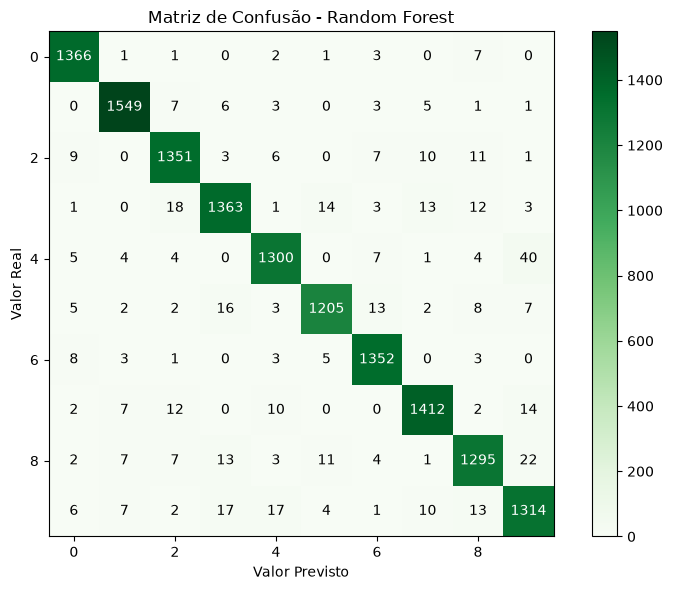

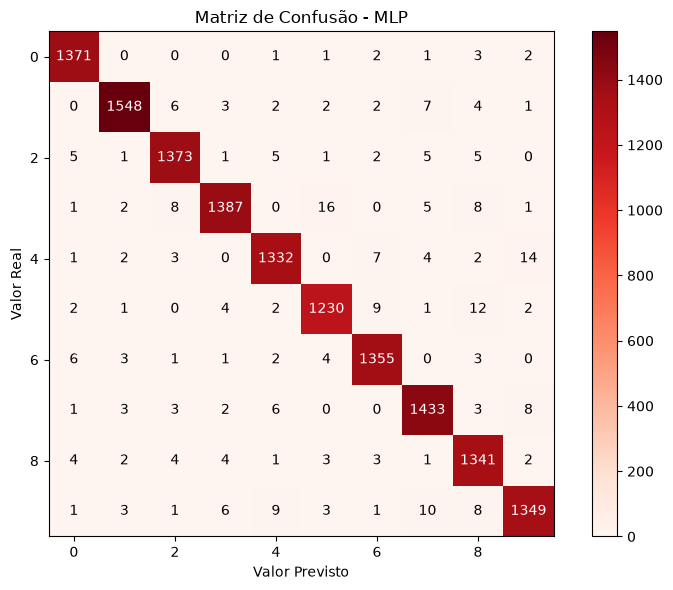

In [37]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, title, cmap):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    plt.xlabel('Valor Previsto')
    plt.ylabel('Valor Real')
    
    # Adicionar números em cada célula
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
    
    plt.tight_layout()
    plt.show()

# Matriz de confusão - KNN
plot_confusion_matrix(cm_knn, 'Matriz de Confusão - KNN', 'Blues')

# Matriz de confusão - Random Forest
plot_confusion_matrix(cm_rf, 'Matriz de Confusão - Random Forest', 'Greens')

# Matriz de confusão - MLP
plot_confusion_matrix(cm_mlp, 'Matriz de Confusão - MLP', 'Reds')

In [38]:
# Valores exatos das matrizes de confusão

print("=== Matriz de Confusão - KNN ===")
print(cm_knn)
print()

print("=== Matriz de Confusão - Random Forest ===")
print(cm_rf)
print()

print("=== Matriz de Confusão - MLP ===")
print(cm_mlp)

=== Matriz de Confusão - KNN ===
[[1375    1    0    0    0    0    3    0    1    1]
 [   0 1565    3    3    1    0    0    3    0    0]
 [  11   11 1341    5    2    0    4   20    4    0]
 [   1    1    6 1387    0   14    1    7    6    5]
 [   2   17    0    0 1304    0    5    2    0   35]
 [   5    3    1    9    1 1216   18    2    2    6]
 [   5    5    0    0    1    3 1359    0    2    0]
 [   2   14    3    0    1    0    0 1429    0   10]
 [   8    8    1   16    2   25    2    2 1291   10]
 [   1    7    0    6   13    2    1   16    2 1343]]

=== Matriz de Confusão - Random Forest ===
[[1366    1    1    0    2    1    3    0    7    0]
 [   0 1549    7    6    3    0    3    5    1    1]
 [   9    0 1351    3    6    0    7   10   11    1]
 [   1    0   18 1363    1   14    3   13   12    3]
 [   5    4    4    0 1300    0    7    1    4   40]
 [   5    2    2   16    3 1205   13    2    8    7]
 [   8    3    1    0    3    5 1352    0    3    0]
 [   2    7   12    0

### Conclusão técnica

A análise das matrizes de confusão mostra que os três modelos apresentaram bom desempenho na classificação dos dígitos do conjunto MNIST, com a maior parte das previsões concentrada na diagonal principal. As principais confusões ocorreram entre alguns dígitos visualmente semelhantes. No KNN, destacam-se as confusões entre 4 e 9, 8 e 5, e 2 e 7. No Random Forest, observa-se maior ocorrência de erros entre 4 e 9, 3 e 2 e 8 e 9. No MLP, apesar de também apresentar algumas confusões, a quantidade de erros foi, de modo geral, menor.

Considerando as métricas calculadas no conjunto de teste, o **MLP apresentou o melhor desempenho**, com Accuracy de **0,979929**, Precision ponderada de **0,979962**, Recall ponderado de **0,979929** e F1-Score ponderado de **0,979927**. O KNN apresentou o segundo melhor resultado, com Accuracy de **0,972143**, enquanto o Random Forest apresentou Accuracy de **0,964786**.

Em relação ao custo computacional, o **KNN apresentou o menor tempo de treinamento, de aproximadamente 0,10 segundo**. O Random Forest levou aproximadamente **42,86 segundos**, enquanto o MLP levou aproximadamente **38,70 segundos**. Portanto, embora o MLP tenha apresentado maior custo computacional que o KNN, seu desempenho foi superior em todas as métricas avaliadas. O Random Forest apresentou o maior tempo de treinamento e desempenho inferior ao MLP. Assim, considerando o equilíbrio entre desempenho preditivo e custo computacional, o **MLP foi o modelo de melhor desempenho para a classificação dos dígitos neste experimento**, enquanto o KNN se destaca pelo baixo tempo de treinamento e também pelo bom desempenho.
